# DATA PREPROCESSING

In [11]:
import numpy as np
from Bio import SeqIO
from Bio.Align import PairwiseAligner
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

# ==============================================================================
# 1. CONFIGURATION & CONSTANTS
# ==============================================================================
SPIKE_START_MOTIF = "ATGTTTGTTTTTCTTGTT"  # First 18 bp of Wuhan S1 gene
S1_NT_LENGTH = 2055                      # Target length (685 amino acid codons * 3 bp)


# ==============================================================================
# 2. HELPER FUNCTIONS FOR EXTRACTION & ALIGNMENT
# ==============================================================================
def load_wuhan_reference_s1(wuhan_fasta_path="wuhan.fasta"):
    """
    Reads wuhan.fasta and extracts the 2055 bp S1 reference sequence.
    """
    record = SeqIO.read(wuhan_fasta_path, "fasta")
    seq_str = str(record.seq).upper()
    
    start_idx = seq_str.find(SPIKE_START_MOTIF)
    if start_idx != -1:
        return seq_str[start_idx : start_idx + S1_NT_LENGTH]
    
    return seq_str[:S1_NT_LENGTH]


def extract_s1_from_genome(sample_record, max_mismatches=3):
    """
    Extracts 2055 bp S1 sequence from a genome record.
    Uses fast exact search first; falls back to a hamming-distance 
    sliding window if start motif has point mutations.
    """
    seq_str = str(sample_record.seq).upper()
    
    # 1. Fast exact motif match
    start_idx = seq_str.find(SPIKE_START_MOTIF)
    if start_idx != -1:
        s1_candidate = seq_str[start_idx : start_idx + S1_NT_LENGTH]
        if len(s1_candidate) == S1_NT_LENGTH:
            return s1_candidate

    # 2. Robust fuzzy search fallback (sliding window across first half of genome)
    motif_len = len(SPIKE_START_MOTIF)
    best_mismatches = max_mismatches + 1
    best_idx = -1
    search_region_len = min(len(seq_str), 15000)  # S gene is always in first 15k bp
    
    for i in range(search_region_len - motif_len):
        window = seq_str[i : i + motif_len]
        mismatches = sum(1 for a, b in zip(window, SPIKE_START_MOTIF) if a != b)
        
        if mismatches < best_mismatches:
            best_mismatches = mismatches
            best_idx = i
            if mismatches == 1:  # Stop early for near-perfect match
                break

    if best_idx != -1 and best_mismatches <= max_mismatches:
        s1_candidate = seq_str[best_idx : best_idx + S1_NT_LENGTH]
        if len(s1_candidate) == S1_NT_LENGTH:
            return s1_candidate

    return None


def calculate_gap_robust_identity(seq1, seq2, global_aligner):
    """
    Calculates pairwise nucleotide identity (%) robust to insertions/deletions (gaps).
    Dividing identical matches by total alignment length (including gaps)
    ensures indels properly penalize the identity score.
    """
    alignment = global_aligner.align(seq1, seq2)[0]
    aligned_seq1, aligned_seq2 = alignment[0], alignment[1]
    
    # Count matching non-gap positions
    matches = sum(n1 == n2 and n1 != '-' for n1, n2 in zip(aligned_seq1, aligned_seq2))
    alignment_length = len(aligned_seq1)
    
    return (matches / alignment_length) * 100.0


# ==============================================================================
# 3. LOAD WUHAN REFERENCE & EXTRACT SAMPLE S1 SEQUENCES
# ==============================================================================
print("1. Loading Wuhan reference and raw FASTA datasets...")
wuhan_s1_ref = load_wuhan_reference_s1("wuhan.fasta")

human_raw = list(SeqIO.parse("human.fasta", "fasta"))
mouse_raw = list(SeqIO.parse("mouse.fasta", "fasta"))

# Extract clean Human genomic S1 sequences (excluding ambiguous 'N' bases)
human_s1_nt = []
for rec in human_raw:
    s1 = extract_s1_from_genome(rec, max_mismatches=3)
    if s1 and "N" not in s1:
        human_s1_nt.append(s1)
        if len(human_s1_nt) == 100:
            break

# Extract clean Mouse genomic S1 sequences
mouse_s1_nt = []
for rec in mouse_raw:
    s1 = extract_s1_from_genome(rec, max_mismatches=3)
    if s1:
        mouse_s1_nt.append(s1)
        if len(mouse_s1_nt) == 100:
            break

print(f"   ✓ Extracted {len(human_s1_nt)} Human S1 genomic sequences.")
print(f"   ✓ Extracted {len(mouse_s1_nt)} Mouse S1 genomic sequences.")


# ==============================================================================
# 4. EXPORT FILTERED GENOMIC FASTAS
# ==============================================================================
print("\n2. Saving extracted genomic S1 sequences to FASTA...")

human_records_out = [
    SeqRecord(Seq(s), id=f"human_S1_{i+1}", description="Extracted genomic S1 (Human)")
    for i, s in enumerate(human_s1_nt)
]
mouse_records_out = [
    SeqRecord(Seq(s), id=f"mouse_S1_{i+1}", description="Extracted genomic S1 (Mouse)")
    for i, s in enumerate(mouse_s1_nt)
]

SeqIO.write(human_records_out, "human_s1.fasta", "fasta")
SeqIO.write(mouse_records_out, "mouse_s1.fasta", "fasta")
print("   ✓ Saved 'human_s1.fasta' and 'mouse_s1.fasta'.")


# ==============================================================================
# 5. FULL DATASET NUCLEOTIDE DIVERGENCE METRICS
# ==============================================================================
print("\n3. Calculating gap-robust nucleotide identity across ALL sequence pairs...")

# Configure global aligner for pairwise identity calculations
global_aligner = PairwiseAligner()
global_aligner.mode = "global"
global_aligner.match_score = 1
global_aligner.mismatch_score = 0
global_aligner.open_gap_score = -2
global_aligner.extend_gap_score = -0.5

# 1. Intra-Human identity (all 4,950 pairs)
human_intra = [
    calculate_gap_robust_identity(human_s1_nt[i], human_s1_nt[j], global_aligner)
    for i in range(len(human_s1_nt))
    for j in range(i + 1, len(human_s1_nt))
]

# 2. Intra-Mouse identity (all 4,950 pairs)
mouse_intra = [
    calculate_gap_robust_identity(mouse_s1_nt[i], mouse_s1_nt[j], global_aligner)
    for i in range(len(mouse_s1_nt))
    for j in range(i + 1, len(mouse_s1_nt))
]

# 3. Inter-Cohort cross-identity (all 10,000 Human vs. Mouse pairs)
inter_cohort = [
    calculate_gap_robust_identity(h, m, global_aligner)
    for h in human_s1_nt
    for m in mouse_s1_nt
]

# Aggregate Statistics
mean_human_id = np.mean(human_intra)
mean_mouse_id = np.mean(mouse_intra)
mean_inter_id = np.mean(inter_cohort)

inter_divergence = 100.0 - mean_inter_id
avg_nt_diffs = (inter_divergence / 100.0) * S1_NT_LENGTH


# ==============================================================================
# 6. DISPLAY RESULTS
# ==============================================================================
print("\n" + "=" * 55)
print("          GENOMIC S1 SEQUENCE ANALYSIS SUMMARY")
print("=" * 55)
print(f"Human Intra-Cohort Identity :  {mean_human_id:.2f}%")
print(f"Mouse Intra-Cohort Identity :  {mean_mouse_id:.2f}%")
print(f"Human vs. Mouse Identity    :  {mean_inter_id:.2f}%")
print("-" * 55)
print(f"Cohort Genomic Divergence   :  {inter_divergence:.2f}%")
print(f"Average Nucleotide Diffs    :  ~{avg_nt_diffs:.1f} bp per S1 gene ({S1_NT_LENGTH} bp total)")
print("=" * 55)

1. Loading Wuhan reference and raw FASTA datasets...
   ✓ Extracted 100 Human S1 genomic sequences.
   ✓ Extracted 87 Mouse S1 genomic sequences.

2. Saving extracted genomic S1 sequences to FASTA...
   ✓ Saved 'human_s1.fasta' and 'mouse_s1.fasta'.

3. Calculating gap-robust nucleotide identity across ALL sequence pairs...

          GENOMIC S1 SEQUENCE ANALYSIS SUMMARY
Human Intra-Cohort Identity :  99.43%
Mouse Intra-Cohort Identity :  98.99%
Human vs. Mouse Identity    :  99.14%
-------------------------------------------------------
Cohort Genomic Divergence   :  0.86%
Average Nucleotide Diffs    :  ~17.7 bp per S1 gene (2055 bp total)


In [12]:
import os
import re
import h5py
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
import shap

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from transformers import AutoConfig, AutoTokenizer, AutoModel
from huggingface_hub import login

# ==============================================================================
# 1. REPRODUCIBILITY & RANDOM SEED SETTING
# ==============================================================================
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)


# ==============================================================================
# 2. FILE PATHS & MODEL CONFIGURATION
# ==============================================================================
# Binary classification targets (FASTA path, Host Label)
FASTA_INPUTS = [
    ("human_s1.fasta", "Human"),
    ("mouse_s1.fasta", "Mouse")
]

# Hugging Face authentication & model selection
HF_TOKEN = "PASTE_YOUR_HF_TOKEN_HERE"  # Replace with your actual token, or set the HF_TOKEN env var
MODEL_NAME = "pabloarozarenad/Vir2vec"

# Output HDF5 file for storing extracted embeddings
OUTPUT_H5_PATH = "human_vs_mouse_vir2vec_s1.h5"

# Transformer execution parameters
BATCH_SIZE = 2       # Small batch size to optimize GPU VRAM usage
MAX_LENGTH = 4096    # Maximum sequence context window (in tokens)


# ==============================================================================
# 3. SEQUENCE TRIMMING & QUALITY CONTROL CONSTANTS
# ==============================================================================
S1_NT_LENGTH = 2055        # Total expected S1 nucleotide length
CUT_S1_S2 = True           # Toggle for removing S1/S2 cleavage region
S1_S2_CUT_START = 2000     # S1/S2 region start (bp)
S1_S2_CUT_END = 2055       # S1/S2 region end (bp)

FILTER_LOW_QUALITY = True   # Discard sequences failing quality thresholds
MAX_AMBIGUOUS_RATIO = 0.00 # Max allowed ratio of ambiguous bases ('N', 'R', etc.)

print("Environment and configuration parameters successfully initialized!")

Environment and configuration parameters successfully initialized!


In [13]:
import os
import re
import numpy as np
import pandas as pd
import torch
from Bio import SeqIO

# ==============================================================================
# 1. SEQUENCE CLEANING & QUALITY CONTROL HELPERS
# ==============================================================================
def clean_sequence(seq: str) -> str:
    """Cleans, normalizes to uppercase, removes whitespace, and converts RNA (U) to DNA (T)."""
    seq = str(seq).strip().upper()
    seq = re.sub(r"\s+", "", seq)  # Strip internal whitespace/newlines
    return seq.replace("U", "T")  # Normalize RNA -> DNA


def is_high_quality_sequence(seq: str, max_ambiguous_ratio: float = 0.0) -> bool:
    """Returns True if the proportion of ambiguous non-ACGT bases is within threshold."""
    if not seq:
        return False
    canonical_bases = {"A", "C", "G", "T"}
    ambiguous_count = sum(1 for base in seq if base not in canonical_bases)
    ratio = ambiguous_count / len(seq)
    return ratio <= max_ambiguous_ratio


# ==============================================================================
# 2. SEQUENCE TRIMMING / REGION EXCISION
# ==============================================================================
def cut_s1_s2_region(seq: str, s1_len: int = 2055, cut_start: int = 2000, cut_end: int = 2055) -> str:
    """Slices S1 subunit (2055 bp) and optionally excises the S1/S2 cleavage junction (bp 2000-2055)."""
    s1_seq = seq[:s1_len]
    if len(s1_seq) >= cut_end:
        return s1_seq[:cut_start] + s1_seq[cut_end:]
    elif len(s1_seq) > cut_start:
        return s1_seq[:cut_start]
    return s1_seq


# ==============================================================================
# 3. FASTA DATASET LOADER
# ==============================================================================
def load_binary_fasta_dataset(
    fasta_inputs: list,
    cut_s1_s2: bool = True,
    s1_len: int = 2055,
    cut_start: int = 2000,
    cut_end: int = 2055,
    filter_low_quality: bool = True,
    max_ambiguous_ratio: float = 0.00
):
    """
    Loads FASTA files, cleans sequences, filters out low-quality entries,
    trims S1/S2 regions, and constructs binary target arrays.
    """
    raw_sequences, raw_labels, raw_headers = [], [], []

    # 1. Load FASTA records using SeqIO
    for file_path, label in fasta_inputs:
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"FASTA file not found at: {file_path}")

        for record in SeqIO.parse(file_path, "fasta"):
            cleaned_seq = clean_sequence(str(record.seq))
            if cleaned_seq:
                raw_sequences.append(cleaned_seq)
                raw_labels.append(label)
                raw_headers.append(record.description)

    # 2. Filter and trim sequences
    processed_seqs, processed_labels, processed_headers = [], [], []
    filtered_out_stats = {"total_raw": len(raw_sequences), "dropped_low_quality": 0}

    for seq, label, header in zip(raw_sequences, raw_labels, raw_headers):
        # Quality Control: Drop sequences exceeding ambiguous base limit
        if filter_low_quality and not is_high_quality_sequence(seq, max_ambiguous_ratio):
            filtered_out_stats["dropped_low_quality"] += 1
            continue

        # Excise S1/S2 cleavage junction or take full S1
        if cut_s1_s2:
            processed_seq = cut_s1_s2_region(seq, s1_len=s1_len, cut_start=cut_start, cut_end=cut_end)
        else:
            processed_seq = seq[:s1_len]

        processed_seqs.append(processed_seq)
        processed_labels.append(label)
        processed_headers.append(header)

    # 3. Generate numeric binary label encoding (alphabetical order)
    label_names = sorted(pd.unique(np.asarray(processed_labels, dtype=object)).tolist())
    label_to_id = {lbl: idx for idx, lbl in enumerate(label_names)}
    label_ids = np.array([label_to_id[lbl] for lbl in processed_labels], dtype=np.int64)

    return (
        processed_seqs,
        processed_labels,
        label_ids,
        label_names,
        processed_headers,
        raw_sequences,
        raw_labels,
        filtered_out_stats
    )


# ==============================================================================
# 4. MASKED MAX-POOLING FOR TRANSFORMER EMBEDDINGS
# ==============================================================================
def enforce_max_pooling(model_output, attention_mask):
    """
    Performs max-pooling over non-padded tokens.
    Padding tokens are masked out with -1e9 (-infinity) before applying max pooling.
    """
    token_embeddings = model_output.last_hidden_state if hasattr(model_output, "last_hidden_state") else model_output[0]
    
    # Expand attention mask to match embedding shape: (batch, seq_len, hidden_dim)
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size())
    
    # Fill padding token embeddings with -1e9 so max() ignores them
    masked_embeddings = token_embeddings.masked_fill(input_mask_expanded == 0, -1e9)
    
    # Take max value across token dimension (dim=1)
    return torch.max(masked_embeddings, dim=1).values

In [14]:
# ==============================================================================
# CELL 4: DATASET LOADING, QUALITY CONTROL AUDITING, & SUMMARY REPORT
# ==============================================================================

# 1. Load and process FASTA datasets using configuration from Cell 2 & helpers from Cell 3
(
    sequences,
    labels,
    label_ids,
    label_names,
    headers,
    raw_sequences,
    raw_labels,
    filter_stats
) = load_binary_fasta_dataset(
    FASTA_INPUTS,
    cut_s1_s2=CUT_S1_S2,
    s1_len=S1_NT_LENGTH,
    cut_start=S1_S2_CUT_START,
    cut_end=S1_S2_CUT_END,
    filter_low_quality=FILTER_LOW_QUALITY,
    max_ambiguous_ratio=MAX_AMBIGUOUS_RATIO
)

# 2. Build class breakdown table (Raw vs. Filtered vs. Dropped)
raw_counts = pd.Series(raw_labels).value_counts().sort_index()
clean_counts = pd.Series(labels).value_counts().sort_index()

summary_df = pd.DataFrame({
    "Raw Count": raw_counts,
    "Filtered Count": clean_counts,
    "Removed (Low Quality)": raw_counts - clean_counts.reindex(raw_counts.index, fill_value=0)
}).fillna(0).astype(int)

# 3. Calculate sequence length statistics
seq_lens = [len(s) for s in sequences]

# 4. Print clean dataset summary report
print("=" * 70)
print("       DATA PREPROCESSING & DATASET SUMMARY (HUMAN VS MOUSE)")
print("=" * 70)
print(f"Total Raw Sequences Read        : {filter_stats['total_raw']}")
print(f"Dropped Low-Quality ([UNK])     : {filter_stats['dropped_low_quality']}")
print(f"Total High-Quality Retained     : {len(sequences)}")
print(f"S1/S2 Region Cut Status         : {'Applied (' + str(S1_S2_CUT_START) + ' to ' + str(S1_S2_CUT_END) + ' bp excised)' if CUT_S1_S2 else 'Not Applied'}")
print(f"Processed Sequence Lengths (bp) : Min={min(seq_lens)}, Mean={int(np.mean(seq_lens))}, Max={max(seq_lens)}")
print("-" * 70)
print("\nClass Breakdown by Host Species:")
print(summary_df.to_string())
print("=" * 70)

       DATA PREPROCESSING & DATASET SUMMARY (HUMAN VS MOUSE)
Total Raw Sequences Read        : 187
Dropped Low-Quality ([UNK])     : 11
Total High-Quality Retained     : 176
S1/S2 Region Cut Status         : Applied (2000 to 2055 bp excised)
Processed Sequence Lengths (bp) : Min=2000, Mean=2000, Max=2000
----------------------------------------------------------------------

Class Breakdown by Host Species:
       Raw Count  Filtered Count  Removed (Low Quality)
Human        100              94                      6
Mouse         87              82                      5


# EMBEDDING EXTRACTION

In [15]:
# ==============================================================================
# CELL 5: MODEL LOADING, BATCHED EMBEDDING EXTRACTION, & HDF5 STORAGE
# ==============================================================================

# 1. Hugging Face Authentication & Compute Device Selection
if HF_TOKEN and HF_TOKEN != "PASTE_YOUR_HF_TOKEN_HERE":
    login(token=HF_TOKEN)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")


# 2. Load Vir2vec Tokenizer, Configuration, & Transformer Model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True, token=HF_TOKEN)
hf_config = AutoConfig.from_pretrained(MODEL_NAME, trust_remote_code=True, token=HF_TOKEN)

# Enforce explicit pad_token_id in configuration
if not hasattr(hf_config, "pad_token_id") or hf_config.pad_token_id is None:
    hf_config.pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0

model = AutoModel.from_pretrained(
    MODEL_NAME,
    config=hf_config,
    trust_remote_code=True,
    low_cpu_mem_usage=False,
    token=HF_TOKEN,
).to(device)

model.eval()  # Set model to evaluation mode (disables dropout)


# 3. Batched Embedding Extraction & Quality Verification
unk_token_id = tokenizer.unk_token_id
total_unk_tokens = 0
embeddings_list = []

print("\nExtracting dense embeddings for Human and Mouse sequence cohorts...")

with torch.no_grad():
    for i in tqdm(range(0, len(sequences), BATCH_SIZE), desc="Extracting Batches"):
        batch_seqs = sequences[i : i + BATCH_SIZE]
        
        # Tokenize sequence batch
        encoded_input = tokenizer(
            batch_seqs,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        ).to(device)

        # Audit for presence of unknown [UNK] tokens
        if unk_token_id is not None:
            total_unk_tokens += (encoded_input["input_ids"] == unk_token_id).sum().item()

        # Transformer forward pass & masked max-pooling
        model_output = model(**encoded_input)
        pooled_embeddings = enforce_max_pooling(model_output, encoded_input["attention_mask"])
        
        embeddings_list.append(pooled_embeddings.float().cpu().numpy())

print(f"--> [UNK] Token Verification: Found {total_unk_tokens} [UNK] tokens in clean dataset.")

# Stack batch arrays into final feature matrix X and target array y
X = np.vstack(embeddings_list)
y = label_ids


# 4. Save Extracted Embeddings & Metadata to Compressed HDF5
with h5py.File(OUTPUT_H5_PATH, "w") as f:
    string_dtype = h5py.string_dtype(encoding="utf-8")
    
    f.create_dataset("embeddings", data=X, compression="gzip")
    f.create_dataset("labels", data=np.asarray(labels, dtype=object), dtype=string_dtype)
    f.create_dataset("label_ids", data=y)
    f.create_dataset("label_names", data=np.asarray(label_names, dtype=object), dtype=string_dtype)

print(f"✓ Embeddings saved to: {OUTPUT_H5_PATH} | Matrix shape: {X.shape}")

Using compute device: cuda


Loading weights: 100%|██████████| 74/74 [00:00<00:00, 709.02it/s]
[transformers] MixtralModel LOAD REPORT from: pabloarozarenad/Vir2vec
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Extracting dense embeddings for Human and Mouse sequence cohorts...


Extracting Batches: 100%|██████████| 88/88 [00:01<00:00, 73.59it/s]


--> [UNK] Token Verification: Found 0 [UNK] tokens in clean dataset.
✓ Embeddings saved to: human_vs_mouse_vir2vec_s1.h5 | Matrix shape: (176, 768)



Running 5-Fold Nested Cross-Validation...

HUMAN VS. MOUSE CLASSIFIER PERFORMANCE (5-FOLD NESTED CV)
              precision    recall  f1-score   support

       Human       0.97      0.99      0.98        94
       Mouse       0.99      0.96      0.98        82

    accuracy                           0.98       176
   macro avg       0.98      0.98      0.98       176
weighted avg       0.98      0.98      0.98       176



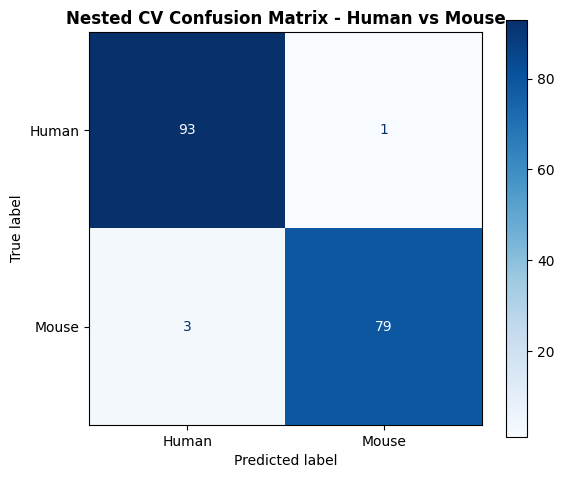

✓ Final classifier fitted on full dataset (Best C = 1.0) for SHAP.


In [17]:
# ==============================================================================
# CELL 6: NESTED CROSS-VALIDATION EVALUATION & FULL DATASET SHAP FIT
# ==============================================================================

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict

# 1. Define Outer (5-Fold) & Inner (3-Fold) Cross-Validation Schemes
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# 2. Define Classifier and Hyperparameter Search Grid
base_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
param_grid = {'C': [0.01, 0.1, 1.0, 10.0]}

# Inner loop estimator (GridSearchCV)
nested_grid_search = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid,
    cv=inner_cv,
    scoring='f1_macro'
)

# 3. Outer Loop Evaluation via Out-of-Fold Predictions
print("\nRunning 5-Fold Nested Cross-Validation...")
y_pred_cv = cross_val_predict(nested_grid_search, X, y, cv=outer_cv)

print("\n" + "=" * 60)
print("HUMAN VS. MOUSE CLASSIFIER PERFORMANCE (5-FOLD NESTED CV)")
print("=" * 60)
print(classification_report(y, y_pred_cv, target_names=label_names))

# 4. Plot Aggregated Out-of-Fold Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_display = ConfusionMatrixDisplay.from_predictions(
    y, 
    y_pred_cv, 
    display_labels=label_names, 
    cmap="Blues", 
    ax=ax
)
plt.title("Nested CV Confusion Matrix - Human vs Mouse", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# 5. Fit Optimal Hyperparameters on Full Dataset for SHAP
final_grid_search = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid,
    cv=inner_cv,
    scoring='f1_macro'
)
final_grid_search.fit(X, y)
clf = final_grid_search.best_estimator_

print(f"✓ Final classifier fitted on full dataset (Best C = {final_grid_search.best_params_['C']}) for SHAP.")

# SHAP

In [21]:
# ==============================================================================
# CELL 7A: MASKED SHAP TRACING & DATASET-WIDE FEATURE EXTRACTION
# ==============================================================================

# 1. Initialize Linear SHAP Explainer on full-dataset model
explainer = shap.LinearExplainer(clf, X)

def trace_shap_to_dna_tokens(seq, model, tokenizer, clf_explainer, target_class_idx, device):
    """
    Traces dimension-level SHAP attributions back to exact DNA tokens using
    masked max-pooling argmax routing, and extracts token start coordinates (bp).
    """
    # Tokenize and extract character offset mapping for genomic coordinates
    inputs = tokenizer(
        [seq], 
        return_tensors="pt", 
        truncation=True, 
        max_length=MAX_LENGTH,
        return_offsets_mapping=True
    ).to(device)

    # Pop offset_mapping to prevent model forward-pass errors
    offset_mapping = inputs.pop("offset_mapping")[0].cpu().numpy()
    input_ids = inputs["input_ids"][0]
    attention_mask = inputs["attention_mask"][0]
    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    
    # Base-pair start coordinate for each token
    token_positions = [offset[0] for offset in offset_mapping]

    with torch.no_grad():
        out = model(**inputs)
        raw_hidden = out.last_hidden_state if hasattr(out, "last_hidden_state") else out[0]
        hidden_states = raw_hidden[0].float()  # (seq_len, hidden_dim)

        # Mask padding and non-biological special tokens with -1e9 before max-pooling
        masked_hidden = hidden_states.clone()
        special_tokens_set = set([
            tokenizer.pad_token, tokenizer.cls_token, tokenizer.sep_token,
            tokenizer.unk_token, tokenizer.bos_token, tokenizer.eos_token,
            "<unk>", "<s>", "</s>", "[PAD]", "[CLS]", "[SEP]"
        ])

        for idx, tok in enumerate(tokens):
            if attention_mask[idx].item() == 0 or tok in special_tokens_set:
                masked_hidden[idx, :] = -1e9

        # Identify winning token index for each dimension d via max-pooling argmax
        argmax_token_indices = torch.argmax(masked_hidden, dim=0).cpu().numpy()
        pooled_embedding = torch.max(masked_hidden, dim=0).values.unsqueeze(0).cpu().numpy()

    # Compute dimension SHAP values from linear classifier
    seq_shap = clf_explainer.shap_values(pooled_embedding)

    # Standardize SHAP output for Target Class 1 (Human)
    if isinstance(seq_shap, list):
        seq_shap = seq_shap[target_class_idx][0]
    elif seq_shap.ndim == 3:
        seq_shap = seq_shap[0, :, target_class_idx]
    else:
        seq_shap = seq_shap[0] if target_class_idx == 1 else -seq_shap[0]

    # Map dimension-level SHAP scores back to winning token positions
    token_shap_scores = np.zeros(len(tokens))
    for dim_idx, tok_idx in enumerate(argmax_token_indices):
        if tok_idx < len(tokens):
            token_shap_scores[tok_idx] += seq_shap[dim_idx]

    return tokens, token_shap_scores, token_positions


# 2. Extract Token Attributions Across ALL Sequences (Target = Class 1 / Human)
TARGET_CLASS_IDX = 1  # Positive SHAP = Human Driver, Negative SHAP = Mouse Driver
token_scores_dict = {}
token_pos_dict = {}

print("Extracting signed SHAP scores and genomic coordinates across ALL sequences...")

for idx, seq in enumerate(sequences):
    tokens, scores, positions = trace_shap_to_dna_tokens(
        seq, model, tokenizer, explainer, TARGET_CLASS_IDX, device
    )
    
    for tok, score, pos in zip(tokens, scores, positions):
        # Ignore non-biological tokens
        if tok in [tokenizer.pad_token, tokenizer.cls_token, tokenizer.sep_token, 
                    "<unk>", "<s>", "</s>", "[PAD]", "[CLS]", "[SEP]"]:
            continue
            
        if tok not in token_scores_dict:
            token_scores_dict[tok] = []
            token_pos_dict[tok] = []
            
        token_scores_dict[tok].append(score)
        token_pos_dict[tok].append(pos)

print(f"✓ Extraction complete! Processed {len(token_scores_dict)} unique k-mers.")

Extracting signed SHAP scores and genomic coordinates across ALL sequences...
✓ Extraction complete! Processed 361 unique k-mers.


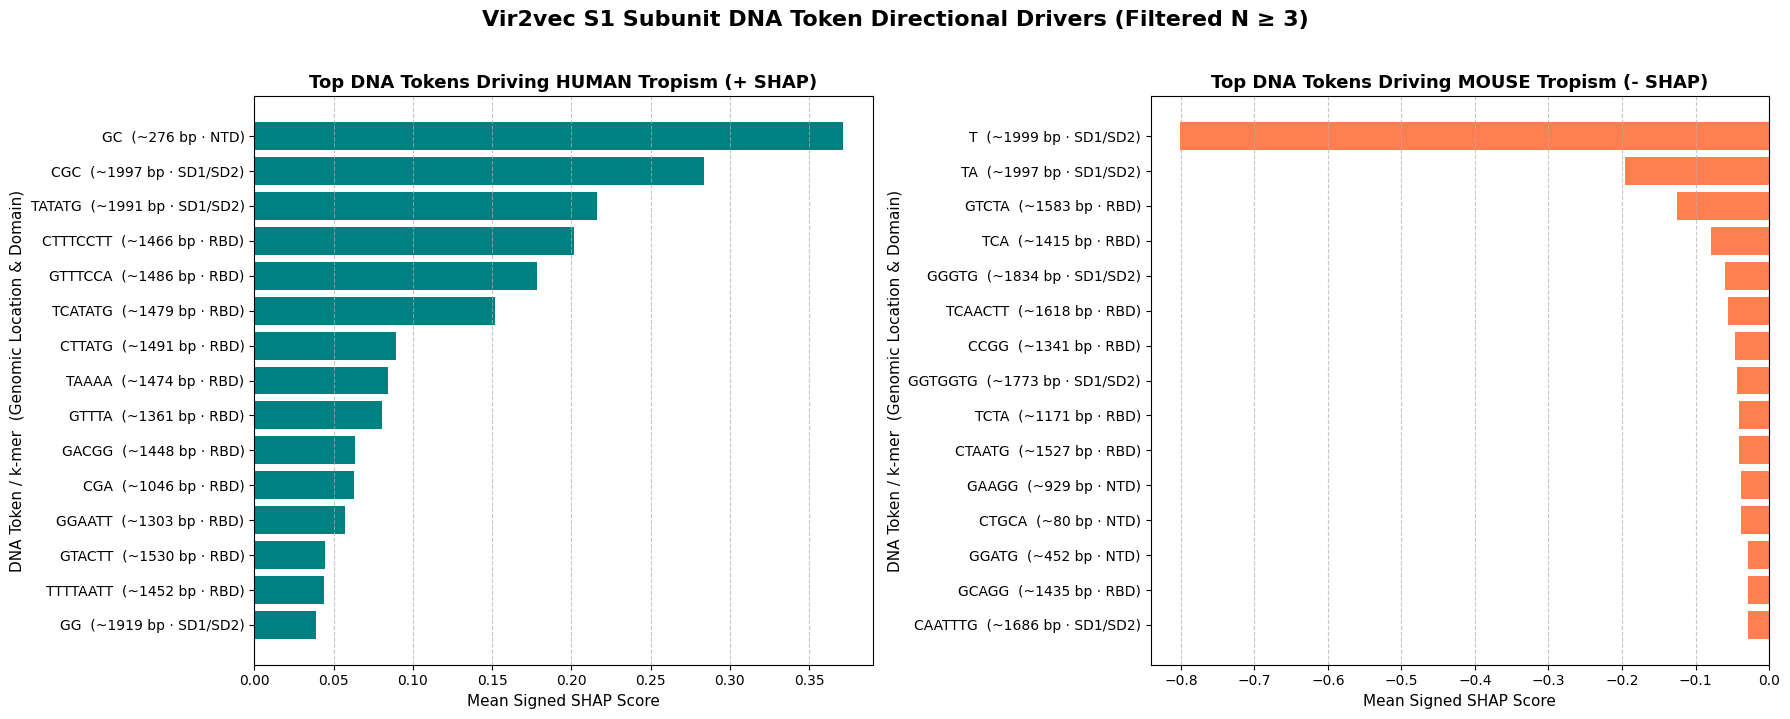

In [22]:
# ==============================================================================
# CELL 7B: K-MER FILTERING, DOMAIN ANNOTATION, & DIRECTIONAL DRIVER PLOT
# ==============================================================================

# Minimum sequence frequency threshold to filter rare k-mer noise
MIN_SEQUENCE_FREQUENCY = 3  # K-mer must appear in at least 3 sequences

def get_s1_domain(bp_pos):
    """Maps nucleotide base-pair position to S1 structural domains."""
    if bp_pos < 40:
        return "SP"
    elif 40 <= bp_pos < 955:
        return "NTD"
    elif 955 <= bp_pos < 1624:
        return "RBD"
    elif 1624 <= bp_pos < 2040:
        return "SD1/SD2"
    else:
        return "S1/S2"


# 1. Aggregate Statistics & Apply Frequency Filtering
kmer_stats = {}

for tok in token_scores_dict:
    # Filter out rare k-mers to avoid single-sequence outlier noise
    if len(token_scores_dict[tok]) < MIN_SEQUENCE_FREQUENCY:
        continue
        
    mean_score = np.mean(token_scores_dict[tok])
    mean_pos = int(np.mean(token_pos_dict[tok]))
    domain = get_s1_domain(mean_pos)
    
    kmer_stats[tok] = {
        "mean_score": mean_score,
        "mean_pos": mean_pos,
        "domain": domain,
        "count": len(token_scores_dict[tok]),
        "display_label": f"{tok}  (~{mean_pos} bp · {domain})"
    }

# 2. Separate Top Human Drivers (+ SHAP) and Top Mouse Drivers (- SHAP)
top_human_kmers = sorted(kmer_stats.items(), key=lambda x: x[1]["mean_score"], reverse=True)[:15]
top_mouse_kmers = sorted(kmer_stats.items(), key=lambda x: x[1]["mean_score"])[:15]


# 3. Plot Side-by-Side Directional Driver Bar Charts
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left Subplot: Human Drivers (+ SHAP)
h_labels = [item[1]["display_label"] for item in top_human_kmers][::-1]
h_scores = [item[1]["mean_score"] for item in top_human_kmers][::-1]

axes[0].barh(h_labels, h_scores, color="teal")
axes[0].set_title("Top DNA Tokens Driving HUMAN Tropism (+ SHAP)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Mean Signed SHAP Score", fontsize=11)
axes[0].set_ylabel("DNA Token / k-mer  (Genomic Location & Domain)", fontsize=11)
axes[0].grid(axis="x", linestyle="--", alpha=0.7)

# Right Subplot: Mouse Drivers (- SHAP)
m_labels = [item[1]["display_label"] for item in top_mouse_kmers][::-1]
m_scores = [item[1]["mean_score"] for item in top_mouse_kmers][::-1]

axes[1].barh(m_labels, m_scores, color="coral")
axes[1].set_title("Top DNA Tokens Driving MOUSE Tropism (- SHAP)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Mean Signed SHAP Score", fontsize=11)
axes[1].set_ylabel("DNA Token / k-mer  (Genomic Location & Domain)", fontsize=11)
axes[1].grid(axis="x", linestyle="--", alpha=0.7)

plt.suptitle("Vir2vec S1 Subunit DNA Token Directional Drivers (Filtered N ≥ 3)", y=1.02, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

Calculating global signed positional profiles across ALL sequences...
✓ Interpolation complete!
   Max Positive SHAP (Human Driver) : +0.026367
   Max Negative SHAP (Mouse Driver) : -0.046972


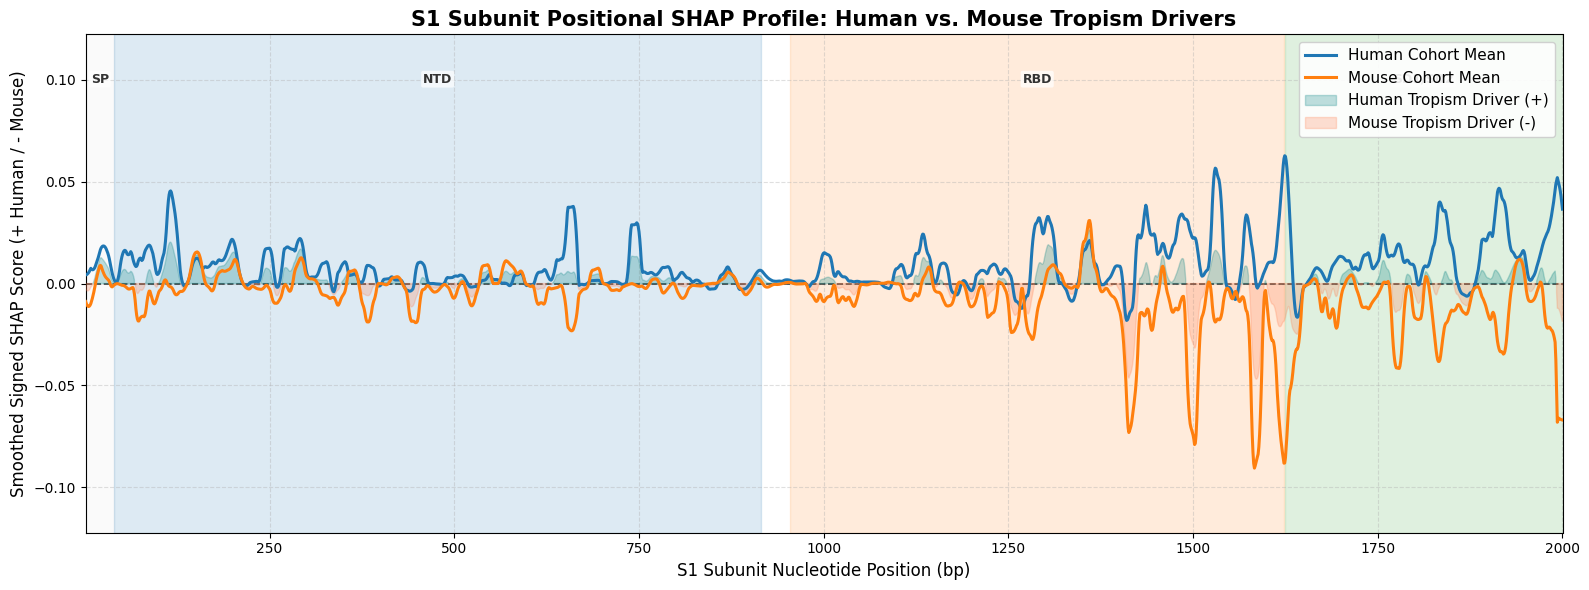

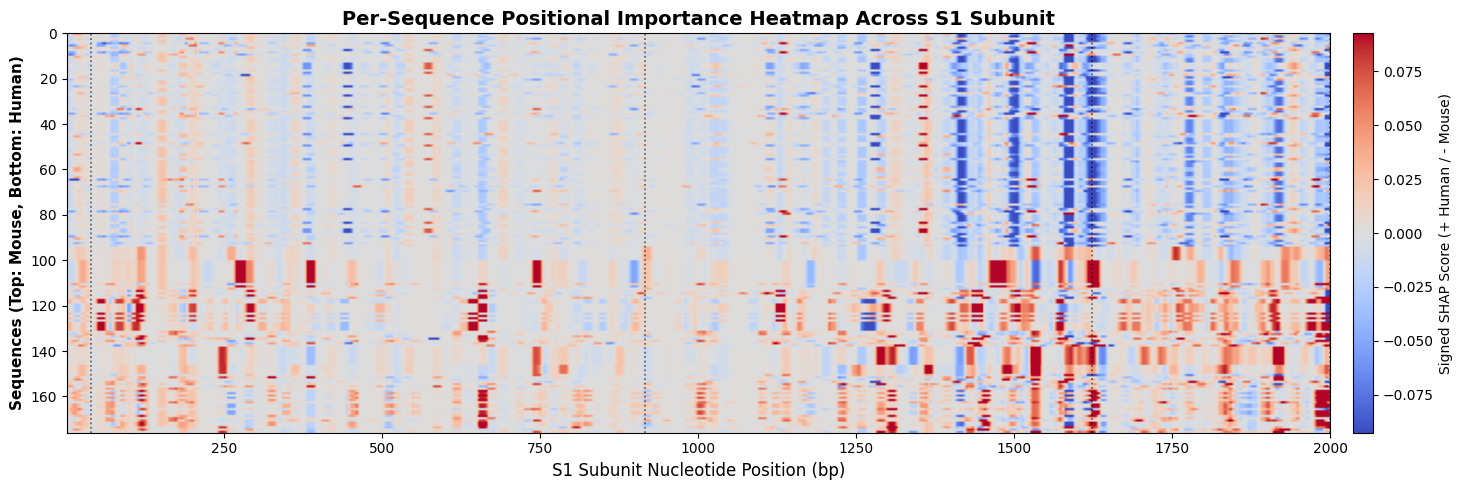

In [24]:
# ==============================================================================
# CELL 8: GLOBAL SIGNED POSITIONAL ATTRIBUTION TRACKS & DOMAIN HEATMAP (FIXED)
# ==============================================================================

REF_LENGTH_BP = max(len(s) for s in sequences)
GRID_POINTS = REF_LENGTH_BP
SMOOTHING_WINDOW = 15  # Reduced slightly to preserve local peak sharpness

# Define S1 domain boundaries based on S1/S2 region cut choice
if CUT_S1_S2:
    S1_DOMAINS = [
        {"name": "SP",      "start": 1,    "end": 39,   "color": "#e0e0e0"},
        {"name": "NTD",     "start": 40,   "end": 915,  "color": "#1f77b4"},
        {"name": "RBD",     "start": 955,  "end": 1623, "color": "#ff7f0e"},
        {"name": "SD1/SD2", "start": 1624, "end": REF_LENGTH_BP, "color": "#2ca02c"},
    ]
else:
    S1_DOMAINS = [
        {"name": "SP",      "start": 1,    "end": 39,   "color": "#e0e0e0"},
        {"name": "NTD",     "start": 40,   "end": 915,  "color": "#1f77b4"},
        {"name": "RBD",     "start": 955,  "end": 1623, "color": "#ff7f0e"},
        {"name": "SD1/SD2", "start": 1624, "end": 2039, "color": "#2ca02c"},
        {"name": "S1/S2",   "start": 2040, "end": 2055, "color": "#d62728"},
    ]

# Special tokens to strip out before spatial interpolation
SPECIAL_TOKENS = set([
    tokenizer.pad_token, tokenizer.cls_token, tokenizer.sep_token,
    tokenizer.unk_token, tokenizer.bos_token, tokenizer.eos_token,
    "<unk>", "<s>", "</s>", "[PAD]", "[CLS]", "[SEP]"
])

TARGET_CLASS_IDX = 1  # Target Class 1 = Human (+ Human Driver, - Mouse Driver)
interpolated_tracks = []

print("Calculating global signed positional profiles across ALL sequences...")

for idx, seq in enumerate(sequences):
    seq_len_bp = len(seq)

    # 1. Trace token SHAP scores and base-pair positions
    tokens, token_scores, positions = trace_shap_to_dna_tokens(
        seq, model, tokenizer, explainer, TARGET_CLASS_IDX, device
    )

    # 2. Filter out non-biological special tokens & zero-offset padding
    valid_positions = []
    valid_scores = []

    for tok, score, pos in zip(tokens, token_scores, positions):
        if tok not in SPECIAL_TOKENS and pos > 0:
            valid_positions.append(pos)
            valid_scores.append(score)

    # Fallback if sequence is too short or offset mapping failed
    if len(valid_positions) == 0:
        valid_positions = list(np.linspace(1, seq_len_bp, len(token_scores)))
        valid_scores = list(token_scores)

    # 3. Aggregate duplicate positions & sort monotonically for np.interp
    pos_score_map = {}
    for pos, score in zip(valid_positions, valid_scores):
        pos_score_map[pos] = pos_score_map.get(pos, 0.0) + score

    sorted_positions = np.array(sorted(pos_score_map.keys()))
    sorted_scores = np.array([pos_score_map[p] for p in sorted_positions])

    # 4. Interpolate onto standardized 1D grid (No np.abs!)
    x_new = np.linspace(1, REF_LENGTH_BP, GRID_POINTS)
    resampled_profile = np.interp(x_new, sorted_positions, sorted_scores)

    # 5. Smooth profile using 1D convolution rolling window
    smoothed_profile = np.convolve(
        resampled_profile,
        np.ones(SMOOTHING_WINDOW) / SMOOTHING_WINDOW,
        mode='same'
    )
    interpolated_tracks.append(smoothed_profile)

# Convert list to 2D numpy matrix: shape (num_sequences, REF_LENGTH_BP)
tracks_matrix = np.array(interpolated_tracks)

# Extract cohort-specific mean profiles
human_indices = np.where(y == 1)[0]
mouse_indices = np.where(y == 0)[0]

human_mean_profile = np.mean(tracks_matrix[human_indices], axis=0)
mouse_mean_profile = np.mean(tracks_matrix[mouse_indices], axis=0)
global_signed_profile = np.mean(tracks_matrix, axis=0)

# --- Diagnostic Verification Print ---
print(f"✓ Interpolation complete!")
print(f"   Max Positive SHAP (Human Driver) : +{np.max(global_signed_profile):.6f}")
print(f"   Max Negative SHAP (Mouse Driver) : {np.min(global_signed_profile):.6f}")


# ------------------------------------------------------------------------------
# PLOT 1: SIGNED 1D POSITIONAL TRACKS ACROSS S1 STRUCTURAL DOMAINS
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 6))
position_axis_bp = np.linspace(1, REF_LENGTH_BP, GRID_POINTS)

# Plot class-specific mean profiles
ax.plot(position_axis_bp, human_mean_profile, label="Human Cohort Mean", color="#1f77b4", linewidth=2.2, zorder=4)
ax.plot(position_axis_bp, mouse_mean_profile, label="Mouse Cohort Mean", color="#ff7f0e", linewidth=2.2, zorder=4)
ax.axhline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.7, zorder=3)

# Fill positive (+ Human) and negative (- Mouse) global attribution zones
ax.fill_between(position_axis_bp, global_signed_profile, 0, where=(global_signed_profile >= 0), color="teal", alpha=0.25, label="Human Tropism Driver (+)", zorder=3)
ax.fill_between(position_axis_bp, global_signed_profile, 0, where=(global_signed_profile < 0), color="coral", alpha=0.25, label="Mouse Tropism Driver (-)", zorder=3)

y_abs_max = max(np.max(np.abs(human_mean_profile)), np.max(np.abs(mouse_mean_profile)), 1e-5) * 1.35
ax.set_ylim(-y_abs_max, y_abs_max)

# Overlay genomic domain background bands
for domain in S1_DOMAINS:
    ax.axvspan(domain["start"], domain["end"], color=domain["color"], alpha=0.15, zorder=1)
    center_pos = (domain["start"] + domain["end"]) / 2
    
    ax.text(
        center_pos, y_abs_max * 0.82, domain["name"],
        horizontalalignment='center', verticalalignment='center',
        fontsize=9, fontweight='bold', color='#333333',
        bbox=dict(boxstyle="round,pad=0.15", facecolor='white', alpha=0.7, edgecolor='none')
    )

ax.set_title("S1 Subunit Positional SHAP Profile: Human vs. Mouse Tropism Drivers", fontsize=15, fontweight="bold")
ax.set_xlabel("S1 Subunit Nucleotide Position (bp)", fontsize=12)
ax.set_ylabel("Smoothed Signed SHAP Score (+ Human / - Mouse)", fontsize=12)
ax.set_xlim(1, REF_LENGTH_BP)
ax.grid(True, linestyle="--", alpha=0.4, zorder=2)
ax.legend(fontsize=11, loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# PLOT 2: PER-SEQUENCE SIGNED HEATMAP (SORTED BY HOST LABEL)
# ------------------------------------------------------------------------------
# Sort sequences so Mouse isolates (y=0) appear at top and Human (y=1) at bottom
sort_indices = np.argsort(y)
sorted_tracks = tracks_matrix[sort_indices]

fig, ax = plt.subplots(figsize=(16, 5))
v_limit = max(np.percentile(np.abs(sorted_tracks), 98), 1e-5)  # Robust color scale limit

im = ax.imshow(
    sorted_tracks,
    aspect='auto',
    cmap='coolwarm',  # Blue (+ Human) vs Red (- Mouse) diverging colormap
    vmin=-v_limit,
    vmax=v_limit,
    extent=[1, REF_LENGTH_BP, len(y), 0]
)

cbar = plt.colorbar(im, ax=ax, label="Signed SHAP Score (+ Human / - Mouse)", pad=0.015)
cbar.ax.tick_params(labelsize=10)

ax.set_xlabel("S1 Subunit Nucleotide Position (bp)", fontsize=12)
ax.set_ylabel("Sequences (Top: Mouse, Bottom: Human)", fontsize=11, fontweight='bold')
ax.set_title("Per-Sequence Positional Importance Heatmap Across S1 Subunit", fontsize=14, fontweight="bold")

# Add vertical domain boundary lines
for domain in S1_DOMAINS:
    ax.axvline(x=domain["end"], color='black', linestyle=':', alpha=0.6, linewidth=1.2)

plt.tight_layout()
plt.show()

Displaying HTML Table in Notebook:


,Rank,Genomic Pos,Domain,Codon #,Ref AA,Mouse Variant(s),Human Cohort AAs,Mouse Cohort AAs,Top K-mer,SHAP Score
0,1,1586 bp,RBD,529,K,"K529N (21%), K529T (7%)","K: 74%, N: 13%, V: 11%, C: 1%","K: 71%, N: 21%, T: 7%",GTCTA,-0.04697
1,2,1413 bp,RBD,471,E,"E471Q (21%), E471Y (7%)","E: 74%, Q: 13%, G: 11%, D: 1%","E: 71%, Q: 21%, Y: 7%",TCA,-0.04644
2,3,1502 bp,RBD,501,N,"N501G (21%), N501V (7%)","N: 51%, Y: 23%, G: 13%, Q: 11%, F: 1%","N: 71%, G: 21%, V: 7%",CTAATG,-0.03174
3,4,1641 bp,SD1/SD2,547,T,T547G (21%),"T: 74%, G: 13%, L: 11%, F: 1%","T: 79%, G: 21%",TCAACTT,-0.02493
4,5,1618 bp,RBD,540,N,N540F (21%),"N: 76%, F: 13%, G: 11%","N: 79%, F: 21%",TCAACTT,-0.02116
5,6,1259 bp,RBD,420,D,"D420Y (21%), D420N (7%)","D: 74%, Y: 13%, L: 11%, G: 1%","D: 71%, Y: 21%, N: 7%",GATGA,-0.01565
6,7,1774 bp,SD1/SD2,592,F,"F592V (21%), F592G (7%)","F: 73%, V: 24%, T: 1%, G: 1%","F: 71%, V: 21%, G: 7%",GGTGGTG,-0.01412
7,8,442 bp,NTD,148,N,"N148S (20%), N148M (1%)","N: 76%, M: 11%, K: 11%, S: 2%","N: 79%, S: 20%, M: 1%",GGATG,-0.01149
8,9,1870 bp,SD1/SD2,624,I,"I624D (21%), I624A (7%), I624H (1%)","I: 73%, D: 13%, L: 11%, V: 1%, H: 1%","I: 70%, D: 21%, A: 7%, H: 1%",GCTATT,-0.01094
9,10,1805 bp,SD1/SD2,602,T,T602S (21%),"T: 73%, S: 13%, Q: 11%, I: 1%, N: 1%","T: 79%, S: 21%",CACCA,-0.00979


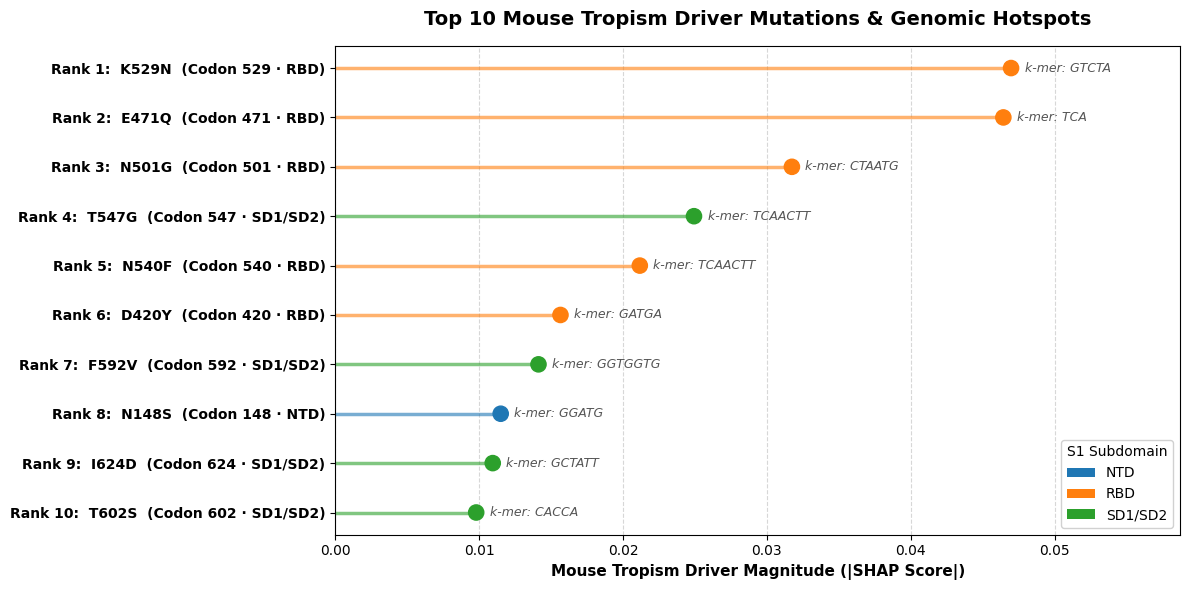

In [29]:
# ==============================================================================
# CELL 9: VISUAL MUTATION DASHBOARD & STYLED JUPYTER DISPLAY
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Bio.Seq import Seq
from scipy.signal import find_peaks
from IPython.display import display, HTML

# Ensure Wuhan S1 reference sequence is available
if 'wuhan_s1_ref' not in globals():
    from Bio import SeqIO
    wuhan_rec = SeqIO.read("wuhan.fasta", "fasta")
    wuhan_s1_ref = str(wuhan_rec.seq).upper()
    start_idx = wuhan_s1_ref.find("ATGTTTGTTTTTCTTGTT")
    if start_idx != -1:
        wuhan_s1_ref = wuhan_s1_ref[start_idx : start_idx + S1_NT_LENGTH]

def get_s1_domain(bp_pos):
    """Maps nucleotide position to S1 structural domains."""
    if bp_pos < 40:
        return "SP"
    elif 40 <= bp_pos < 955:
        return "NTD"
    elif 955 <= bp_pos < 1624:
        return "RBD"
    elif 1624 <= bp_pos < 2040:
        return "SD1/SD2"
    else:
        return "S1/S2"


# 1. Locate Top 10 Negative SHAP Peaks (Mouse Drivers)
profile_to_search = -global_signed_profile
peak_indices, _ = find_peaks(profile_to_search, distance=21)

peak_shap_values = global_signed_profile[peak_indices]
top_peak_indices = peak_indices[np.argsort(peak_shap_values)[:10]]

# Extract Human and Mouse sequence cohorts
human_indices = np.where(y == 1)[0]
mouse_indices = np.where(y == 0)[0]

human_sequences = [sequences[i] for i in human_indices]
mouse_sequences = [sequences[i] for i in mouse_indices]


# 2. Extract Data Rows
table_rows = []

for rank, peak_pos_0idx in enumerate(top_peak_indices, 1):
    peak_bp = peak_pos_0idx + 1  # 1-indexed base-pair position
    shap_val = global_signed_profile[peak_pos_0idx]
    domain = get_s1_domain(peak_bp)
    
    # Codon position (1-indexed AA residue)
    codon_num = ((peak_bp - 1) // 3) + 1
    codon_start_idx = (codon_num - 1) * 3
    codon_end_idx = codon_start_idx + 3
    
    # Wuhan Ref codon & AA
    ref_codon = wuhan_s1_ref[codon_start_idx:codon_end_idx]
    ref_aa = str(Seq(ref_codon).translate()) if len(ref_codon) == 3 else "?"
    
    # Translate codons across cohorts
    human_aas = [str(Seq(seq[codon_start_idx:codon_end_idx]).translate()) 
                 for seq in human_sequences if len(seq) >= codon_end_idx]
    mouse_aas = [str(Seq(seq[codon_start_idx:codon_end_idx]).translate()) 
                 for seq in mouse_sequences if len(seq) >= codon_end_idx]
    
    # Frequency distributions (%)
    h_counts = pd.Series(human_aas).value_counts(normalize=True) * 100
    m_counts = pd.Series(mouse_aas).value_counts(normalize=True) * 100
    
    h_str = ", ".join([f"{aa}: {pct:.0f}%" for aa, pct in h_counts.items()])
    m_str = ", ".join([f"{aa}: {pct:.0f}%" for aa, pct in m_counts.items()])
    
    # Detect Key Mouse Variants
    mouse_variants = [f"{ref_aa}{codon_num}{aa} ({m_counts[aa]:.0f}%)" 
                      for aa in m_counts.index if aa != ref_aa]
    variant_str = ", ".join(mouse_variants) if mouse_variants else "Conserved / Synonymous"
    
    # Primary mutation string for plot axis label
    primary_variant = mouse_variants[0].split()[0] if mouse_variants else f"{ref_aa}{codon_num} (WT)"

    # Find overlapping k-mer
    overlapping_kmers = []
    for tok, pos_list in token_pos_dict.items():
        for p in pos_list:
            if abs(p - peak_bp) <= 10 and tok in kmer_stats:
                overlapping_kmers.append((tok, kmer_stats[tok]["mean_score"]))
                break
    overlapping_kmers.sort(key=lambda x: x[1])
    top_kmer_str = overlapping_kmers[0][0] if overlapping_kmers else "N/A"

    table_rows.append({
        "Rank": rank,
        "Genomic Pos": f"{peak_bp} bp",
        "Domain": domain,
        "Codon #": codon_num,
        "Ref AA": ref_aa,
        "Mouse Variant(s)": variant_str,
        "Human Cohort AAs": h_str,
        "Mouse Cohort AAs": m_str,
        "Top K-mer": top_kmer_str,
        "SHAP Score": shap_val,
        "_raw_bp": peak_bp,
        "_primary_var": primary_variant
    })

mouse_peaks_df = pd.DataFrame(table_rows)


# ==============================================================================
# DISPLAY OPTION 1: JUPYTER HTML STYLED DATAFRAME
# ==============================================================================
display_df = mouse_peaks_df.drop(columns=["_raw_bp", "_primary_var"]).copy()

def color_domain(val):
    colors = {
        "NTD": "background-color: #e8f4f8; color: #1f77b4; font-weight: bold;",
        "RBD": "background-color: #fff3e0; color: #e65100; font-weight: bold;",
        "SD1/SD2": "background-color: #e8f5e9; color: #2e7d32; font-weight: bold;",
        "SP": "background-color: #f5f5f5; color: #616161; font-weight: bold;"
    }
    return colors.get(val, "")

styled_table = (
    display_df.style
    .map(color_domain, subset=["Domain"])
    .background_gradient(subset=["SHAP Score"], cmap="Reds_r")
    .format({"SHAP Score": "{:.5f}"})
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '6px 12px')]}
    ])
)

print("Displaying HTML Table in Notebook:")
display(styled_table)


# ==============================================================================
# DISPLAY OPTION 2: LOLLIPOP MUTATION SUMMARY PLOT
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 6))

plot_df = mouse_peaks_df.iloc[::-1].reset_index(drop=True)  # Reverse so Rank 1 is at top

# Color map per domain
domain_colors = {"NTD": "#1f77b4", "RBD": "#ff7f0e", "SD1/SD2": "#2ca02c", "SP": "#7f7f7f"}
colors = [domain_colors.get(d, "#333333") for d in plot_df["Domain"]]

y_positions = np.arange(len(plot_df))
x_values = np.abs(plot_df["SHAP Score"])  # Plot magnitude of mouse drive

# Draw horizontal lines and dots
ax.hlines(y=y_positions, xmin=0, xmax=x_values, color=colors, alpha=0.6, linewidth=2.5)
ax.scatter(x_values, y_positions, color=colors, s=120, zorder=3)

# Add custom axis labels combining Mutation, Codon, and Domain
y_labels = [
    f"Rank {row['Rank']}:  {row['_primary_var']}  (Codon {row['Codon #']} · {row['Domain']})" 
    for _, row in plot_df.iterrows()
]
ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels, fontsize=10, fontweight="bold")

# Annotate each dot with its top k-mer
for y_pos, x_val, kmer in zip(y_positions, x_values, plot_df["Top K-mer"]):
    ax.text(x_val + (max(x_values) * 0.02), y_pos, f"k-mer: {kmer}", 
            va='center', fontsize=9, color="#555555", fontstyle="italic")

ax.set_xlabel("Mouse Tropism Driver Magnitude (|SHAP Score|)", fontsize=11, fontweight="bold")
ax.set_title("Top 10 Mouse Tropism Driver Mutations & Genomic Hotspots", fontsize=14, fontweight="bold", pad=15)
ax.set_xlim(0, max(x_values) * 1.25)
ax.grid(axis="x", linestyle="--", alpha=0.5)

# Add legend for domains
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=dom) for dom, color in domain_colors.items() if dom in plot_df["Domain"].values]
ax.legend(handles=legend_elements, title="S1 Subdomain", loc="lower right", framealpha=0.9)

plt.tight_layout()
plt.show()